# 07 — Cadmium: Marasi's Trap

The pulser's metal. A cadmium bubble is bendalloy's mirror — time runs
*slower* inside — and the satisfying engineering fact of this notebook is
that **the engine needed zero new code**. `SpeedBubble` always accepted
`time_factor < 1`; we just never turned the dial that way. Everything below
runs on the machinery notebooks 05 and 06 already verified.

What cadmium is *for*, tactically, is stranger than bendalloy: you don't use
it to act faster — you use it to make someone else arrive **later**. The
books' canonical use (Marasi, repeatedly) is the waiting game: trap yourself
or your enemy in slowed time so that the outside world — reinforcements,
rescue, the law — gets there in what feels like moments.

Four experiments: time inverted, bullets into molasses, the healing prison,
and Marasi's gambit proper.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Health, GoldFeruchemy, Poison, SpeedBubble


def run_sampling(world, duration_seconds, sample):
    times, values = [], []
    for _ in range(int(duration_seconds / world.dt_seconds)):
        world.step()
        times.append(world.time_seconds)
        values.append(sample())
    return np.array(times), np.array(values)

## Experiment A — time, inverted

The mirror of notebook 05's first plot: two identical balls dropped from 5 m,
one inside a 0.2× cadmium bubble. It should land five times *later*.

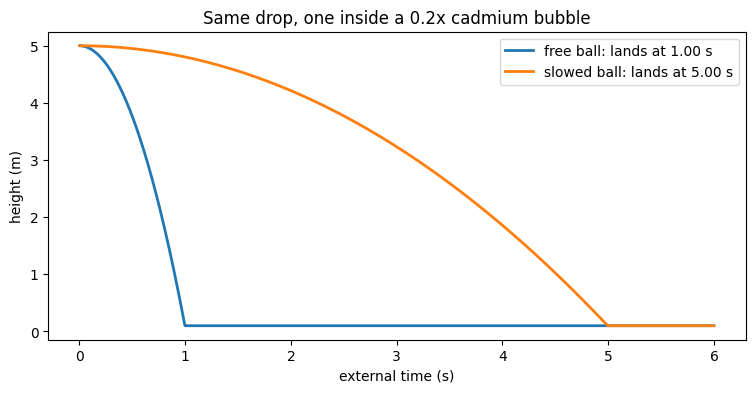

In [2]:
world = World()
free_ball = world.add_body(Body("free ball", 1.0, (0, 5), radius_m=0.1))
slow_ball = world.add_body(Body("slowed ball", 1.0, (10, 5), radius_m=0.1))
world.add_bubble(SpeedBubble(center=(10, 3), radius_m=3.5, time_factor=0.2))
world.run(6.0)

figure, ax = plt.subplots(figsize=(9, 4))
for name in ["free ball", "slowed ball"]:
    data = world.history.body(name)
    landing = data["t"][np.argmax(data["on_ground"])]
    ax.plot(data["t"], data["y"], linewidth=2, label=f"{name}: lands at {landing:.2f} s")
ax.set_xlabel("external time (s)")
ax.set_ylabel("height (m)")
ax.set_title("Same drop, one inside a 0.2x cadmium bubble")
ax.legend()
plt.show()

## Experiment B — bullets into molasses, and a retraction

A 20 m/s projectile crosses a 5 m-radius cadmium bubble. Inside, it should
cover ground at 4 m/s of external speed (20 × 0.2) — from outside you can
*watch* it crawl — and exit at its untouched 20 m/s.

**And a correction.** An earlier draft claimed bubbles bend trajectories
(bendalloy "dips" the ball, cadmium "flattens" it). That was unverified
narration, and it's false on paper before it's false in the sim: the spatial
path y(x) comes from eliminating time from the equations of motion, and the
bubble only rescales time — so the time factor cancels out of the path
entirely. **Bubbles change *when*, never *where*.** This experiment now fires
the same shot with and without the bubble and overlays the paths to prove it.

Two real consequences survive the retraction:

- The "sniper exploit" (flatter long shots through cadmium) does not exist.
  What bubbles actually trade is **timing**: a cadmium-crossing bullet hangs
  in the air twice as long (dodgeable); a bendalloy-crossing one arrives
  early (less reaction time for whoever stands behind the bubble).
- Since time scaling provably cannot bend a path, canon's boundary
  deflection can only come from **shear on extended bodies** — the nose and
  tail living at different time rates (Elliott's hypothesis). That theory is
  now load-bearing, and the two-point rigid bullet experiment is its test.

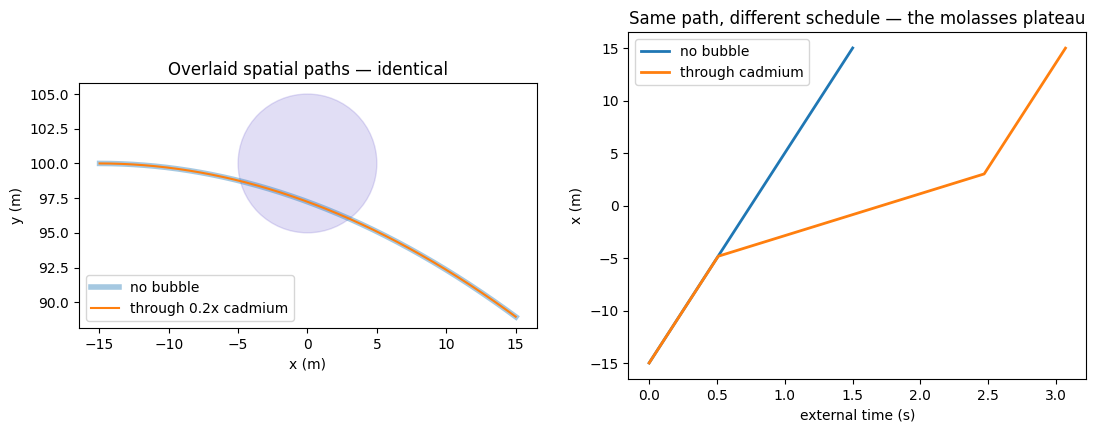

max spatial path deviation: 0.15 cm (integration error only)
flight time, external: free 1.50 s, through cadmium 3.07 s
exit vx: 20.0 m/s (expect 20, untouched — same emergence as bendalloy)


In [3]:
def fire_ball(time_factor):
    world = World(dt_seconds=1.0 / 1000.0)
    ball = world.add_body(Body("ball", 1.0, (-15, 100), velocity=(20, 0), radius_m=0.1))
    if time_factor:
        world.add_bubble(SpeedBubble(center=(0, 100), radius_m=5, time_factor=time_factor))
    while ball.position[0] < 15:
        world.step()
    return world.history.body("ball"), world.time_seconds, ball.velocity[0]

free_shot, free_flight, _ = fire_ball(None)
slow_shot, slow_flight, exit_vx = fire_ball(0.2)

figure, (ax_path, ax_x) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_path.plot(free_shot["x"], free_shot["y"], linewidth=4, alpha=0.4, label="no bubble")
ax_path.plot(slow_shot["x"], slow_shot["y"], linewidth=1.5, label="through 0.2x cadmium")
ax_path.add_patch(plt.Circle((0, 100), 5, color="slateblue", alpha=0.2))
ax_path.set_xlabel("x (m)"); ax_path.set_ylabel("y (m)")
ax_path.set_title("Overlaid spatial paths — identical")
ax_path.set_aspect("equal")
ax_path.legend()

ax_x.plot(free_shot["t"], free_shot["x"], linewidth=2, label="no bubble")
ax_x.plot(slow_shot["t"], slow_shot["x"], linewidth=2, label="through cadmium")
ax_x.set_xlabel("external time (s)"); ax_x.set_ylabel("x (m)")
ax_x.set_title("Same path, different schedule — the molasses plateau")
ax_x.legend()
plt.show()

x_grid = np.linspace(-14.9, 14.9, 500)
path_deviation = np.abs(np.interp(x_grid, slow_shot["x"], slow_shot["y"])
                        - np.interp(x_grid, free_shot["x"], free_shot["y"])).max()
print(f"max spatial path deviation: {path_deviation * 100:.2f} cm (integration error only)")
print(f"flight time, external: free {free_flight:.2f} s, through cadmium {slow_flight:.2f} s")
print(f"exit vx: {exit_vx:.1f} m/s (expect 20, untouched — same emergence as bendalloy)")

## Experiment C — the healing prison

Notebook 05 proved a bendalloy bubble multiplies Wayne's healing as seen from
outside. The mirror: shove the wounded Bloodmaker into a *cadmium* bubble and
his recovery crawls — the same wound takes five times longer to close in
external time. A slow bubble is a weapon against regenerators: it doesn't
hurt them, it takes their healing off the battlefield clock.

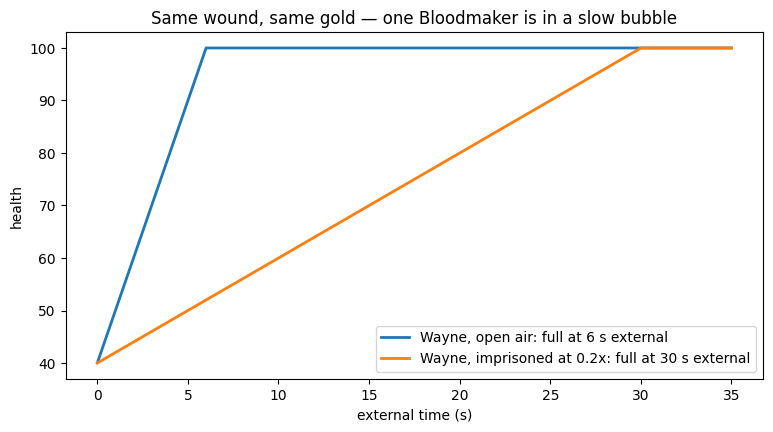

In [4]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, factor in [("Wayne, open air", None), ("Wayne, imprisoned at 0.2x", 0.2)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0))
    goldmind = world.add_power(GoldFeruchemy(health, initial_reserve_health_points=100))
    if factor:
        world.add_bubble(SpeedBubble(center=(0, 0.3), radius_m=2, time_factor=factor))
    health.damage(60)
    goldmind.tap(10)
    times, hp = run_sampling(world, 35.0, lambda: health.current)
    full = times[hp >= 99.9]
    ax.plot(times, hp, linewidth=2,
            label=f"{label}: full at {full[0]:.0f} s external" if len(full) else label)

ax.set_xlabel("external time (s)")
ax.set_ylabel("health")
ax.set_title("Same wound, same gold — one Bloodmaker is in a slow bubble")
ax.legend(loc="lower right")
plt.show()

## Experiment D — Marasi's gambit

The canonical use, quantified. Wayne has been poisoned: 5 HP/s, no gold, no
natural healing — a clean death sentence in 20 seconds. Help is coming, but
it's **60 external seconds away**.

Open air: he dies at 20 s and the rescue finds a body. Inside a 0.2× cadmium
bubble, his 20 lethal seconds stretch across 100 external ones — when the
antidote arrives at t = 60, he's only 12 seconds poisoned on his own clock.
The bubble doesn't fight the venom (notebook 05 proved it can't); it moves
the *deadline*.

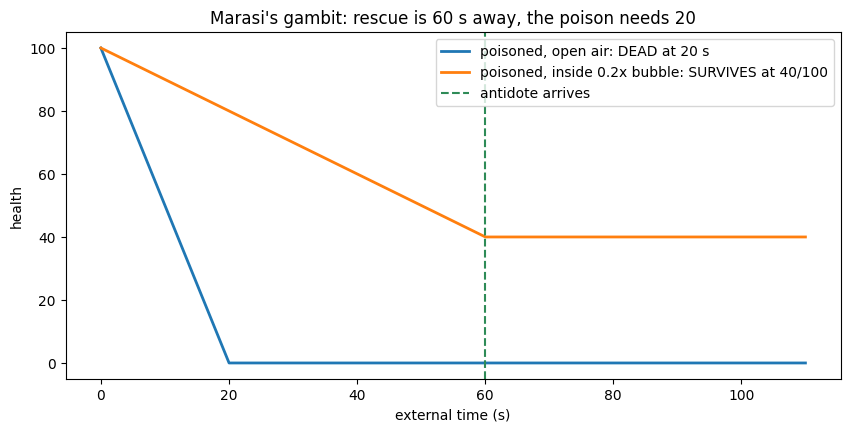

In [5]:
RESCUE_AT_SECONDS = 60.0
figure, ax = plt.subplots(figsize=(10, 4.5))

for label, factor in [("poisoned, open air", None), ("poisoned, inside 0.2x bubble", 0.2)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0))
    poison = world.add_power(Poison(health, damage_per_second=5))
    if factor:
        world.add_bubble(SpeedBubble(center=(0, 0.3), radius_m=2, time_factor=factor))

    times, hp = [], []
    for _ in range(int(110.0 / world.dt_seconds)):
        world.step()
        if world.time_seconds >= RESCUE_AT_SECONDS:
            poison.active = False  # the antidote arrives
        times.append(world.time_seconds)
        hp.append(health.current)
    times, hp = np.array(times), np.array(hp)

    outcome = (f"DEAD at {times[np.argmax(hp <= 0)]:.0f} s" if (hp <= 0).any()
               else f"SURVIVES at {hp[-1]:.0f}/100")
    ax.plot(times, hp, linewidth=2, label=f"{label}: {outcome}")

ax.axvline(RESCUE_AT_SECONDS, color="seagreen", linestyle="--", label="antidote arrives")
ax.set_xlabel("external time (s)")
ax.set_ylabel("health")
ax.set_title("Marasi's gambit: rescue is 60 s away, the poison needs 20")
ax.legend(loc="upper right")
plt.show()

## Findings

1. **Cadmium cost nothing**: every experiment ran on existing machinery with
   the dial below 1. The time model generalized for free, which is the best
   evidence yet that it's the right shape.
2. **Bubbles change *when*, never *where*** — the load-bearing correction of
   this notebook. The overlaid shots deviate by millimeters (integration
   error); an earlier claim that bubbles dip or flatten trajectories was
   retracted. Corollaries: no trajectory exploits exist in either direction,
   bubbles trade only *timing* (hang time vs reaction time), and canon's
   boundary deflection can only come from shear on extended bodies — the
   two-point rigid bullet is now the decisive pending experiment.
3. **Slow bubbles are anti-regenerator weapons**: the same wound that closes
   in 6 s closes in 30 when the Bloodmaker is imprisoned at 0.2×. You don't
   out-damage a healer; you take their healing off the battlefield clock.
   (And a cadmium prison plus patience is a way to besiege a Compounder
   without touching his gold — though it stretches his gold budget too.)
4. **Marasi's gambit checks out exactly**: a 20-second death sentence with
   rescue 60 seconds out is fatal in open air and comfortably survivable
   (12 s experienced, 40/100 health) inside the bubble. Cadmium doesn't
   fight anything — it renegotiates deadlines. That's why the books give it
   to the thoughtful character.
5. **Next (08): steel feruchemy.** Canon verified (Coppermind): steel stores
   *physical speed* — tapping moves the body many times faster, storing
   feels like molasses — and it has nothing to do with aging or local time
   (age storage is atium's job). So a Steelrunner is NOT a personal bubble:
   a bubble rescales your whole local clock (healing, poison, aging
   included) and can never add velocity; F-steel adds real kinetic state
   that the world keeps, while your chemistry ticks at normal rate. The sim
   will make that distinction measurable.